In [2]:
from IPython import display
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as mostrar
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# 1. Cargar dataset raw
# ------------------------------------------------------------

RAW_PATH = "../Data/NASA_Exoplanet_Archive_Data.csv"
df_raw = pd.read_csv(RAW_PATH)
TARGET = "discoverymethod"

print("Dataset cargado correctamente.")
print(f"Filas originales: {df_raw.shape[0]}")

Dataset cargado correctamente.
Filas originales: 36418


In [3]:
# ------------------------------------------------------------
# 2. Filtrado Inicial (Default Flag y Target)
# ------------------------------------------------------------

df = df_raw[df_raw["default_flag"] == 1].copy()
df = df.dropna(subset=[TARGET]).copy()
df = df.reset_index(drop=True)

print(f"Filas después de filtros básicos: {len(df)}")
print(f"Planetas únicos: {df['pl_name'].nunique()}")

Filas después de filtros básicos: 5757
Planetas únicos: 5757


Distribución del target (Datos Únicos):


discoverymethod
Transit            4304
Radial Velocity    1080
Microlensing        230
Others              143
Name: count, dtype: int64

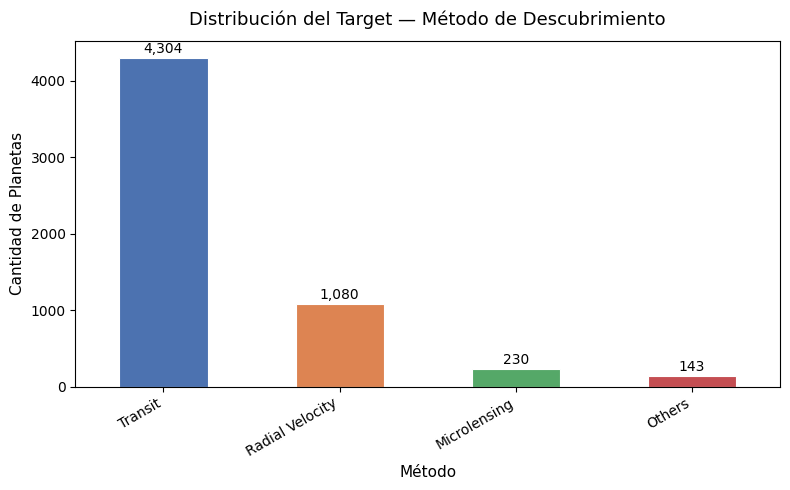

In [4]:
# ------------------------------------------------------------
# 3. Agrupar Categorías del Target
# ------------------------------------------------------------

main_methods = ['Transit', 'Radial Velocity', 'Microlensing']
df[TARGET] = df[TARGET].apply(lambda x: x if x in main_methods else 'Others')

print("Distribución del target (Datos Únicos):")
counts = df[TARGET].value_counts()
mostrar(counts)

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
counts.plot(kind='bar', color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
plt.title("Distribución del Target — Método de Descubrimiento", fontsize=13, pad=12)
plt.xlabel("Método", fontsize=11)
plt.ylabel("Cantidad de Planetas", fontsize=11)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------
# 4. Mitigación de Data Leakage
# ------------------------------------------------------------

id_cols              = ["pl_name", "hostname"]
metadata_cols        = ["pl_refname", "st_refname", "sy_refname", "rowupdate",
                        "pl_pubdate", "releasedate", "soltype"]
discovery_proc_cols  = ["disc_year", "disc_facility"]
coord_text_cols      = ["rastr", "decstr"]
technical_cols       = ["default_flag", "ttv_flag", "pl_bmassprov", "st_metratio"]
redundant_unit_cols  = ["pl_radj", "pl_bmassj"]
error_lim_cols       = [col for col in df.columns if col.endswith(("err1", "err2", "lim"))]

cols_to_drop = (id_cols + metadata_cols + discovery_proc_cols +
                coord_text_cols + technical_cols + redundant_unit_cols + error_lim_cols)

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")
print(f"Columnas eliminadas: {len(cols_to_drop)}")
print(f"Shape después de mitigación: {df.shape}")

Columnas eliminadas: 69
Shape después de mitigación: (5757, 22)


Columnas con valores nulos:


,nulos,porcentaje_nulos
pl_insol,5026,87.3024
st_spectype,4601,79.9201
pl_eqt,4306,74.7959
pl_orbeccen,3403,59.1106
pl_bmasse,3051,52.9964
pl_orbsmax,2220,38.5618
st_met,1710,29.7030
pl_rade,1415,24.5788
st_logg,984,17.0922
st_mass,751,13.0450


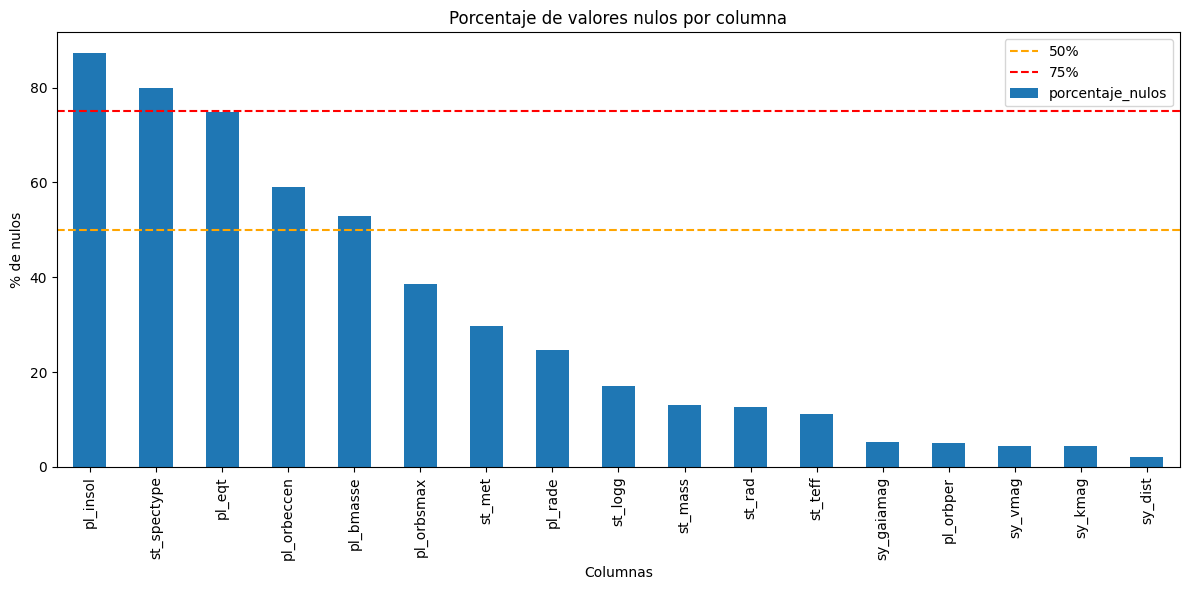

In [6]:
# ------------------------------------------------------------
# 5. Analizar nulos
# ------------------------------------------------------------

null_summary = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": df.isnull().mean() * 100
}).sort_values("porcentaje_nulos", ascending=False)

null_summary_nonzero = null_summary[null_summary["nulos"] > 0]

print("Columnas con valores nulos:")
mostrar(null_summary_nonzero)

plt.figure(figsize=(12, 6))
null_summary_nonzero["porcentaje_nulos"].plot(kind="bar")
plt.axhline(50, linestyle="--", label="50%", color="orange")
plt.axhline(75, linestyle="--", label="75%", color="red")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("% de nulos")
plt.legend()
plt.tight_layout()
plt.show()

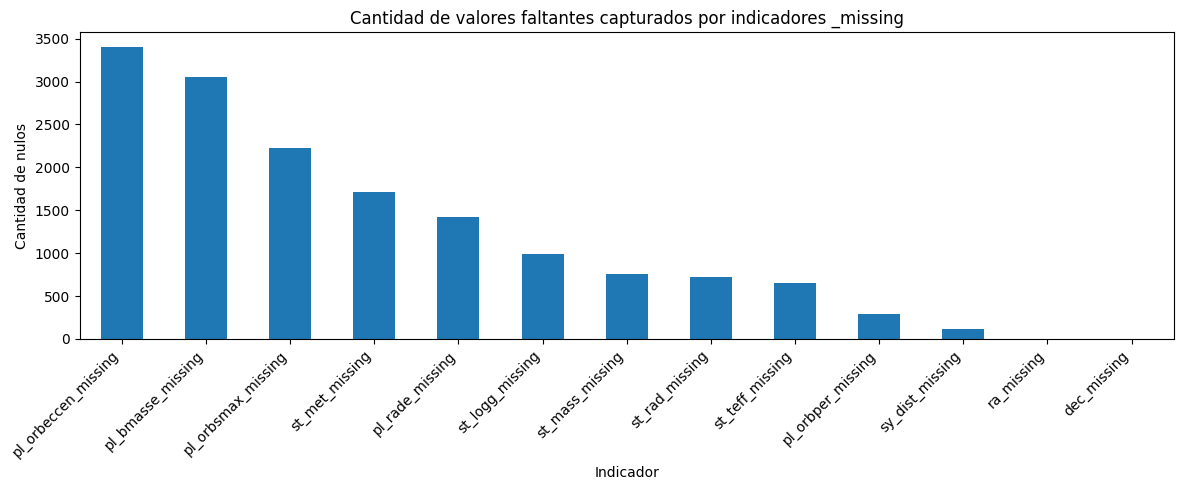

In [7]:
# ------------------------------------------------------------
# 6. Capturar Ausencia Informativa (_missing)
# ------------------------------------------------------------

missing_signal_cols = [
    "pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
    "st_teff", "st_rad", "st_mass", "st_met", "st_logg", "sy_dist", "ra", "dec"
]
missing_signal_cols = [col for col in missing_signal_cols if col in df.columns]

for col in missing_signal_cols:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

missing_indicators = [f"{col}_missing" for col in missing_signal_cols]
missing_counts = df[missing_indicators].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing_counts.plot(kind="bar")
plt.title("Cantidad de valores faltantes capturados por indicadores _missing")
plt.xlabel("Indicador")
plt.ylabel("Cantidad de nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# ------------------------------------------------------------
# 7. Eliminar columnas con nulos excesivos (>75%)
# ------------------------------------------------------------

high_null_cols   = null_summary[null_summary["porcentaje_nulos"] > 75].index.tolist()
protected_cols   = [TARGET] + missing_signal_cols + missing_indicators
cols_to_drop_hn  = [col for col in high_null_cols if col not in protected_cols]

df = df.drop(columns=cols_to_drop_hn, errors="ignore")
print(f"Columnas eliminadas por nulos excesivos: {cols_to_drop_hn}")
print(f"Shape final de datos únicos: {df.shape}")

Columnas eliminadas por nulos excesivos: ['pl_insol', 'st_spectype']
Shape final de datos únicos: (5757, 33)


In [9]:
# ------------------------------------------------------------
# 8. Consistencia Física
# ------------------------------------------------------------

positive_cols = ["pl_rade", "pl_bmasse", "pl_orbper", "pl_orbsmax",
                 "st_teff", "st_rad", "st_mass", "sy_dist"]
positive_cols = [col for col in positive_cols if col in df.columns]

# Excentricidad orbital debe estar en [0, 1]
if "pl_orbeccen" in df.columns:
    df.loc[(df["pl_orbeccen"] < 0) | (df["pl_orbeccen"] > 1), "pl_orbeccen"] = np.nan

invalid_summary = []
for col in positive_cols:
    invalid_count = (df[col] < 0).sum()
    invalid_summary.append({"columna": col, "valores_negativos": invalid_count})
    if invalid_count > 0:
        df.loc[df[col] < 0, col] = np.nan

mostrar(pd.DataFrame(invalid_summary))
print("Consistencia física validada.")

,columna,valores_negativos
0,pl_rade,0
1,pl_bmasse,0
2,pl_orbper,0
3,pl_orbsmax,0
4,st_teff,0
5,st_rad,0
6,st_mass,0
7,sy_dist,0


Consistencia física validada.


In [10]:
# ------------------------------------------------------------
# 9. Transformación Logarítmica (sobre datos crudos ANTES del split)
# NOTA: log1p es una transformación determinista — no genera leakage
# porque no aprende ningún parámetro del dataset.
# ------------------------------------------------------------

skewed_cols = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "sy_dist"]
skewed_cols = [c for c in skewed_cols if c in df.columns]

df_before_processing = df.copy()  # snapshot para visualización

for col in skewed_cols:
    df[col] = np.log1p(df[col])

print(f"Log-transform aplicado a: {skewed_cols}")

Log-transform aplicado a: ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'sy_dist']


Train: 4605 filas | Test: 1152 filas

Distribución train:


discoverymethod
Transit            3443
Radial Velocity     864
Microlensing        184
Others              114
Name: count, dtype: int64


Distribución test:


discoverymethod
Transit            861
Radial Velocity    216
Microlensing        46
Others              29
Name: count, dtype: int64

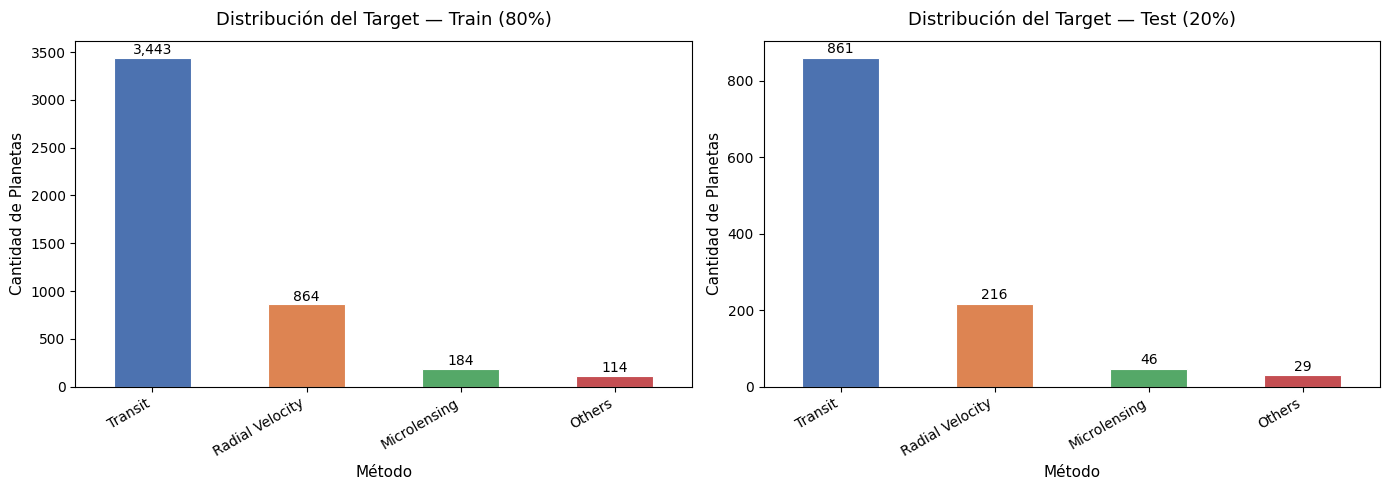

In [11]:
# ============================================================
# 10. Train / Test Split  ← DEBE HACERSE ANTES de KNN y SMOTE
# ============================================================
# IMPORTANTE: KNNImputer y SMOTE se fitean SOLO sobre train.
# Si se fitean sobre el dataset completo, datos de test "filtran"
# información al modelo, inflando artificialmente las métricas.
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("\nDistribución train:")
mostrar(y_train.value_counts())
print("\nDistribución test:")
mostrar(y_test.value_counts())

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, titulo in zip(
    axes,
    [y_train.value_counts(), y_test.value_counts()],
    ["Train (80%)", "Test (20%)"]
):
    counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
    ax.set_title(f"Distribución del Target — {titulo}", fontsize=13, pad=12)
    ax.set_xlabel("Método", fontsize=11)
    ax.set_ylabel("Cantidad de Planetas", fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xticklabels(counts.index, ha='right')
    for i, v in enumerate(counts):
        ax.text(i, v + 5, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------
# 11. Winsorización — fit en train, transform en ambos
# ------------------------------------------------------------
# Recorta valores extremos al percentil 1 y 99 de cada columna.
# Esto elimina las concentraciones extremas que SMOTE luego
# amplifica al generar muestras sintéticas en esas zonas.
# Se fitea SOLO en train para evitar leakage.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
winsorize_cols = [col for col in numeric_cols if not col.endswith("_missing")]

# Aprender límites solo en train
lower_bounds = X_train[winsorize_cols].quantile(0.01)
upper_bounds = X_train[winsorize_cols].quantile(0.99)

# Aplicar a train y test
X_train[winsorize_cols] = X_train[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)
X_test[winsorize_cols] = X_test[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)

print(f"Winsorización aplicada a {len(winsorize_cols)} columnas (p1-p99).")
print("Filas eliminadas: 0 — solo se recortan los valores extremos.")

Winsorización aplicada a 19 columnas (p1-p99).
Filas eliminadas: 0 — solo se recortan los valores extremos.


In [13]:
# ------------------------------------------------------------
# 12. Imputación KNN — fit en train, transform en ambos
# ------------------------------------------------------------
# Las columnas _missing (0/1) no tienen NaNs: se excluyen del
# imputer para no distorsionar las distancias KNN.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_no_missing = [col for col in numeric_cols if not col.endswith("_missing")]

imputer = KNNImputer(n_neighbors=5)
X_train[numeric_no_missing] = imputer.fit_transform(X_train[numeric_no_missing])  # fit + transform
X_test[numeric_no_missing]  = imputer.transform(X_test[numeric_no_missing])        # solo transform

# Categóricas: imputar con 'Unknown'
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown")
    X_test[col]  = X_test[col].fillna("Unknown")

print("Imputación KNN completada (sin leakage).")

Imputación KNN completada (sin leakage).


Distribución TRAIN balanceado con SMOTEENN (11591 filas):


discoverymethod
Microlensing       3388
Others             3067
Radial Velocity    2798
Transit            2338
Name: count, dtype: int64

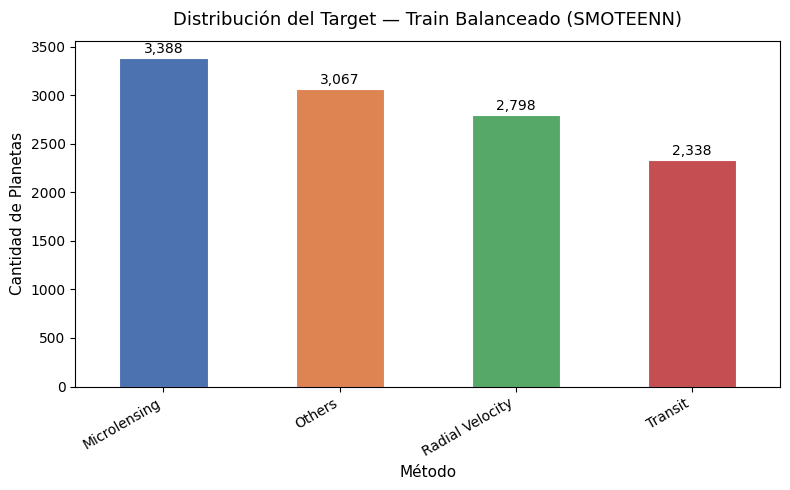


Distribución TEST sin modificar (1152 filas):


discoverymethod
Transit            861
Radial Velocity    216
Microlensing        46
Others              29
Name: count, dtype: int64

In [14]:
# ------------------------------------------------------------
# 13. Balanceo con SMOTEENN — solo sobre TRAIN
# ------------------------------------------------------------

# SMOTEENN = SMOTE + Edited Nearest Neighbours (ENN)
#   · SMOTE genera muestras sintéticas interpolando entre vecinos.
#   · ENN luego ELIMINA las muestras (reales y sintéticas) que
#     son clasificadas incorrectamente por sus vecinos más cercanos.
# Resultado: distribución más suave y limpia que SMOTE solo,
# porque ENN borra los sintéticos que cayeron en zonas densas
# (justo donde se formaban los picos).
# El test set NUNCA se toca — refleja la distribución real.
# ------------------------------------------------------------

# Encodear columnas categóricas para SMOTEENN (requiere valores numéricos)
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str).apply(
        lambda v: v if v in le.classes_ else le.classes_[0]
    ))
    encoders[col] = le

# Encodear target
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc  = le_target.transform(y_test)

# Aplicar SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal_enc = smoteenn.fit_resample(X_train, y_train_enc)

# Reconstruir DataFrames con nombres de columnas
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_train_bal = pd.Series(le_target.inverse_transform(y_train_bal_enc), name=TARGET)

print(f"Distribución TRAIN balanceado con SMOTEENN ({len(X_train_bal)} filas):")
counts_bal = y_train_bal.value_counts()
mostrar(counts_bal)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.figure(figsize=(8, 5))
counts_bal.plot(kind='bar', color=colors[:len(counts_bal)], edgecolor='white', linewidth=0.8)
plt.title("Distribución del Target — Train Balanceado (SMOTEENN)", fontsize=13, pad=12)
plt.xlabel("Método", fontsize=11)
plt.ylabel("Cantidad de Planetas", fontsize=11)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts_bal):
    plt.text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nDistribución TEST sin modificar ({len(X_test)} filas):")
mostrar(y_test.value_counts())

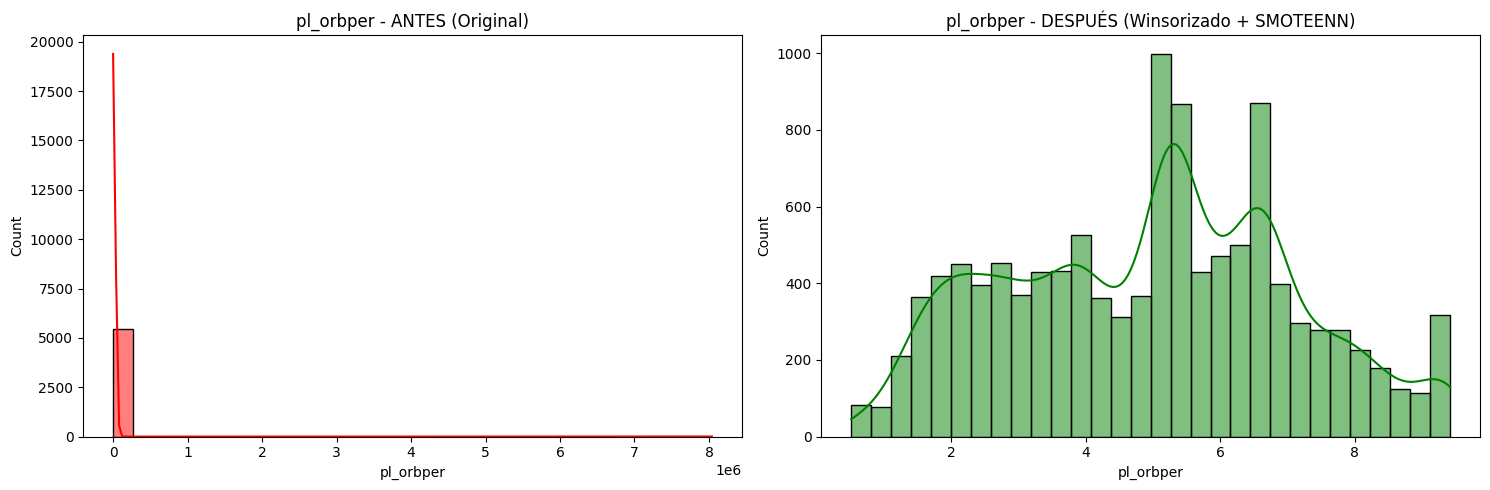

--- Tabla de frecuencias: pl_orbper ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.5096,1.4002,369
1,1.4002,2.2907,1234
2,2.2907,3.1812,1218
3,3.1812,4.0718,1387
4,4.0718,4.9623,1038
5,4.9623,5.8529,2294
6,5.8529,6.7434,1840
7,6.7434,7.6340,971
8,7.6340,8.5245,684
9,8.5245,9.4150,556


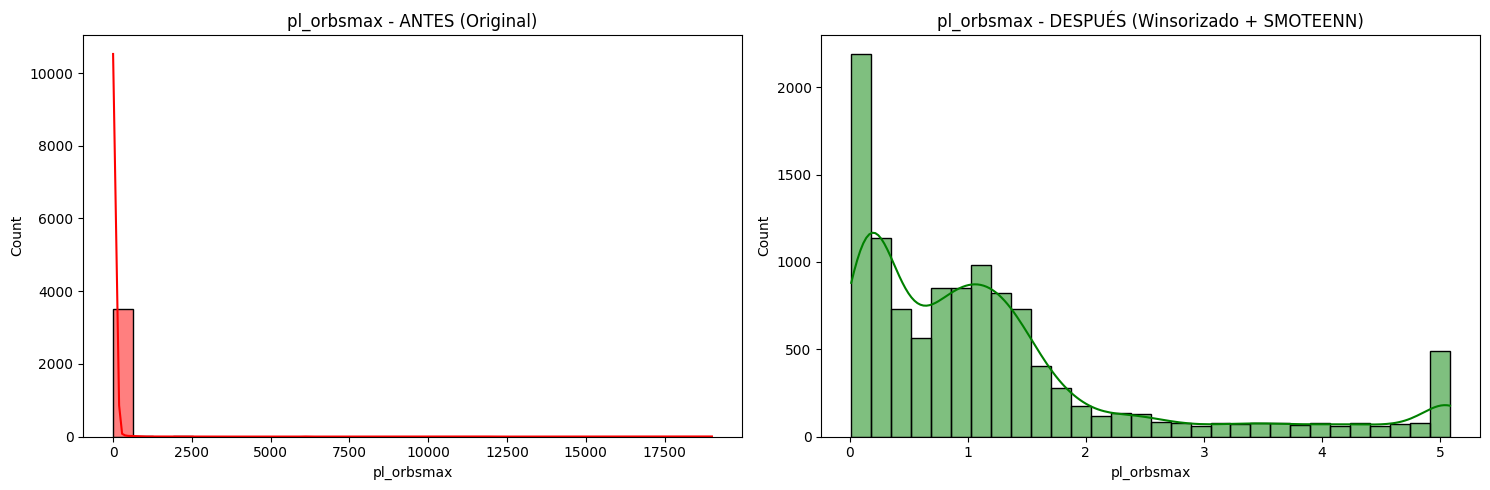

--- Tabla de frecuencias: pl_orbsmax ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.0140,0.5210,4055
1,0.5210,1.0281,2262
2,1.0281,1.5351,2530
3,1.5351,2.0422,857
4,2.0422,2.5492,384
5,2.5492,3.0562,220
6,3.0562,3.5633,230
7,3.5633,4.0703,220
8,4.0703,4.5774,197
9,4.5774,5.0844,636


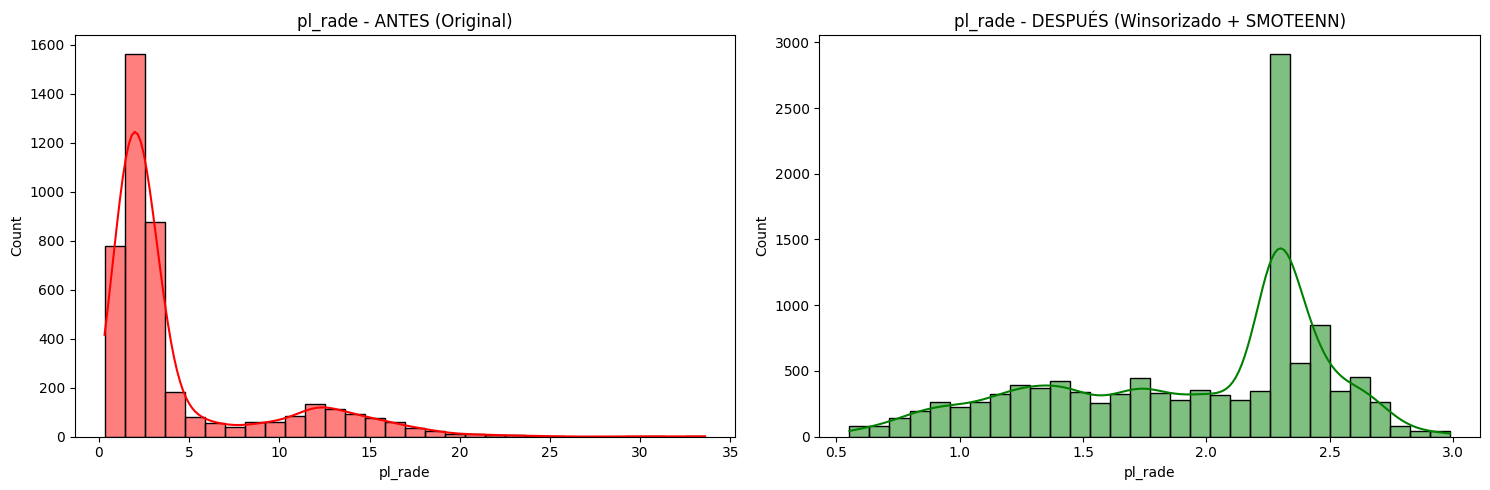

--- Tabla de frecuencias: pl_rade ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.5539,0.7972,303
1,0.7972,1.0405,679
2,1.0405,1.2838,981
3,1.2838,1.5271,1137
4,1.5271,1.7704,1030
5,1.7704,2.0137,964
6,2.0137,2.2570,947
7,2.2570,2.5003,4321
8,2.5003,2.7436,1065
9,2.7436,2.9868,164


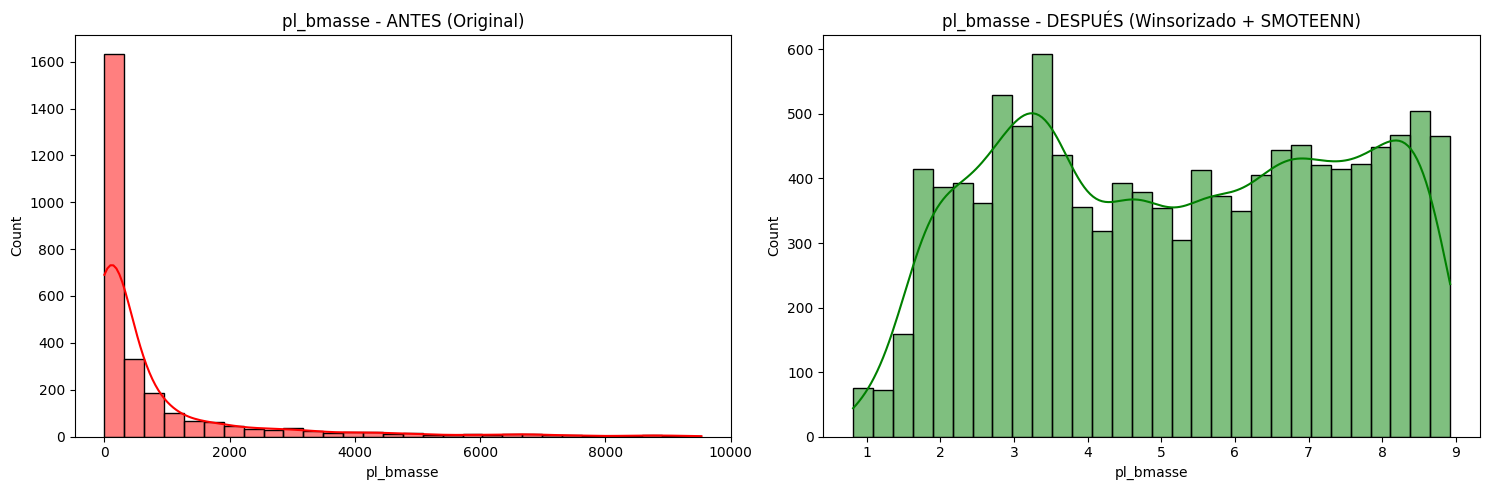

--- Tabla de frecuencias: pl_bmasse ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.8151,1.6259,307
1,1.6259,2.4367,1194
2,2.4367,3.2475,1373
3,3.2475,4.0583,1385
4,4.0583,4.8691,1091
5,4.8691,5.6799,1071
6,5.6799,6.4907,1128
7,6.4907,7.3015,1317
8,7.3015,8.1123,1287
9,8.1123,8.9231,1438


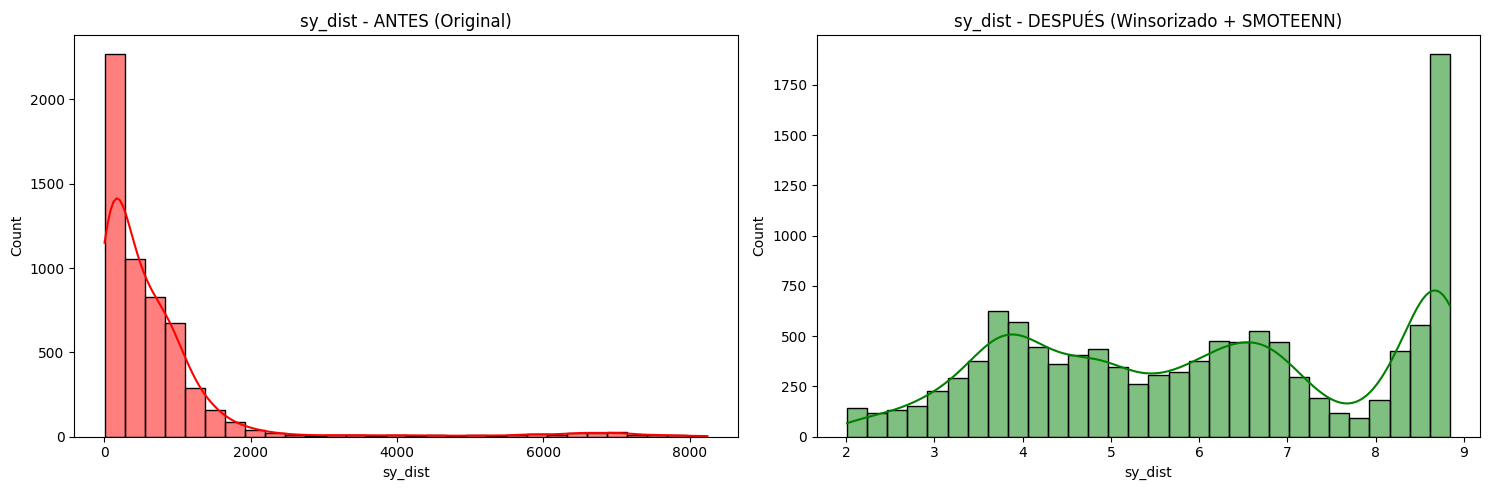

--- Tabla de frecuencias: sy_dist ---


,Rango_Inicio,Rango_Fin,Cantidad
0,2.0124,2.6951,386
1,2.6951,3.3778,672
2,3.3778,4.0604,1574
3,4.0604,4.7431,1212
4,4.7431,5.4258,1041
5,5.4258,6.1085,1004
6,6.1085,6.7912,1470
7,6.7912,7.4738,958
8,7.4738,8.1565,389
9,8.1565,8.8392,2885



ETL finalizado correctamente.
Objetos disponibles para modelado:
  X_train_bal, y_train_bal  → entrenamiento (Winsorizado + SMOTEENN)
  X_test,      y_test       → evaluación   (distribución real, sin modificar)


In [15]:
# ------------------------------------------------------------
# 14. Visualización Comparativa
# ANTES: dataset crudo (con outliers y skew)
# DESPUÉS: train post-Winsorización + SMOTEENN
# ------------------------------------------------------------

cols_to_plot = [c for c in ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "sy_dist"] if c in X_train_bal.columns]

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ANTES (datos originales, escala raw)
    sns.histplot(df_before_processing[col].dropna(), kde=True, ax=axes[0], color="red", bins=30)
    axes[0].set_title(f"{col} - ANTES (Original)")

    # DESPUÉS (train con log1p + SMOTEENN)
    sns.histplot(X_train_bal[col], kde=True, ax=axes[1], color="green", bins=30)
    axes[1].set_title(f"{col} - DESPUÉS (Winsorizado + SMOTEENN)")

    plt.tight_layout()
    plt.show()

    # Tabla de Frecuencias
    counts, bin_edges = np.histogram(X_train_bal[col], bins=10)
    tabla = pd.DataFrame({
        "Rango_Inicio": bin_edges[:-1].round(4),
        "Rango_Fin"   : bin_edges[1:].round(4),
        "Cantidad"    : counts
    })
    print(f"--- Tabla de frecuencias: {col} ---")
    mostrar(tabla)

print("\nETL finalizado correctamente.")
print("Objetos disponibles para modelado:")
print("  X_train_bal, y_train_bal  → entrenamiento (Winsorizado + SMOTEENN)")
print("  X_test,      y_test       → evaluación   (distribución real, sin modificar)")

In [16]:
# ============================================================
# 15. Modelado y Extracción de Patrones (Sprint 3)
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Definición de Algoritmos y Parámetros
# ------------------------------------------------------------
# Random Forest: Robusto frente a varianza, excelente para datasets con muchas features
rf_params = {
    'n_estimators': 150,     # Cantidad de árboles en el bosque
    'max_depth': 12,         # Profundidad máxima para evitar overfitting
    'min_samples_split': 5,  # Mínimo de muestras para dividir un nodo
    'random_state': 42,
    'class_weight': 'balanced' # Compensación extra por si SMOTEENN dejó leves desbalances
}
rf_model = RandomForestClassifier(**rf_params)

# Gradient Boosting: Algoritmo secuencial, optimiza los errores del árbol anterior
gb_params = {
    'n_estimators': 150,
    'learning_rate': 0.1,    # Tasa de aprendizaje (qué tanto corrige cada árbol)
    'max_depth': 5,          # Profundidad menor que RF porque tiende más al overfitting
    'random_state': 42
}
gb_model = GradientBoostingClassifier(**gb_params)

print("Entrenando Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)

print("Entrenando Gradient Boosting...")
gb_model.fit(X_train_bal, y_train_bal)
print("Entrenamiento completado.\n")

# 2. Evaluación en el Test Set (Distribución Real)
# ------------------------------------------------------------
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

print("="*60)
print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

print("="*60)
print("REPORTE DE CLASIFICACIÓN - GRADIENT BOOSTING")
print("="*60)
print(classification_report(y_test, y_pred_gb))

Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenamiento completado.

REPORTE DE CLASIFICACIÓN - RANDOM FOREST
                 precision    recall  f1-score   support

   Microlensing       0.98      1.00      0.99        46
         Others       0.71      0.93      0.81        29
Radial Velocity       0.94      0.95      0.95       216
        Transit       1.00      0.98      0.99       861

       accuracy                           0.98      1152
      macro avg       0.91      0.97      0.93      1152
   weighted avg       0.98      0.98      0.98      1152

REPORTE DE CLASIFICACIÓN - GRADIENT BOOSTING
                 precision    recall  f1-score   support

   Microlensing       0.96      1.00      0.98        46
         Others       0.71      0.86      0.78        29
Radial Velocity       0.97      0.98      0.97       216
        Transit       1.00      0.99      0.99       861

       accuracy                           0.98      1152
      macro avg       0.

In [17]:
# ============================================================
# 16. Modelo Base: Regresión Logística Multinomial
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La Regresión Logística es sensible a la escala de las variables.
# El scaler se ajusta SOLO con train para evitar data leakage.
scaler_lr = StandardScaler()
X_train_bal_scaled = scaler_lr.fit_transform(X_train_bal)
X_test_scaled = scaler_lr.transform(X_test)

lr_params = {
    'C': 1.0,                 # Inverso de la regularización
    'max_iter': 3000,
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'random_state': 42
}
lr_model = LogisticRegression(**lr_params)

print("Entrenando Regresión Logística Multinomial...")
lr_model.fit(X_train_bal_scaled, y_train_bal)
y_pred_lr = lr_model.predict(X_test_scaled)

print("="*60)
print("REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA")
print("="*60)
print(classification_report(y_test, y_pred_lr))


Entrenando Regresión Logística Multinomial...
REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA
                 precision    recall  f1-score   support

   Microlensing       1.00      1.00      1.00        46
         Others       0.35      0.86      0.50        29
Radial Velocity       0.92      0.91      0.92       216
        Transit       1.00      0.95      0.97       861

       accuracy                           0.94      1152
      macro avg       0.82      0.93      0.85      1152
   weighted avg       0.97      0.94      0.95      1152



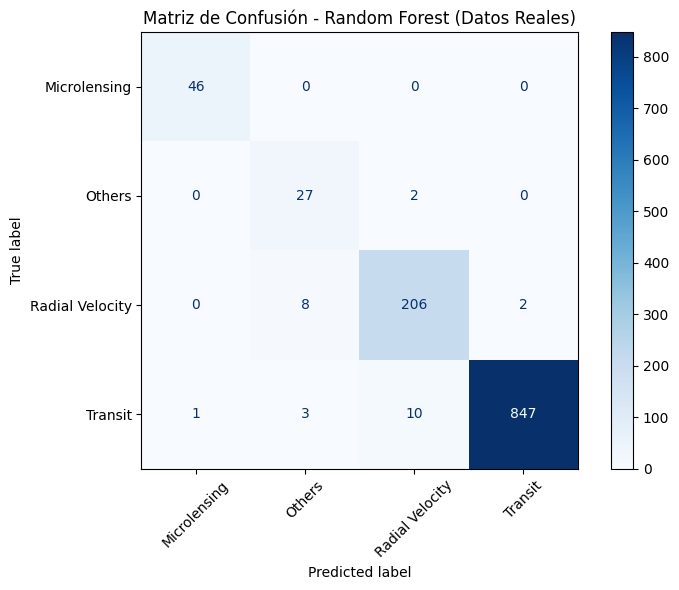

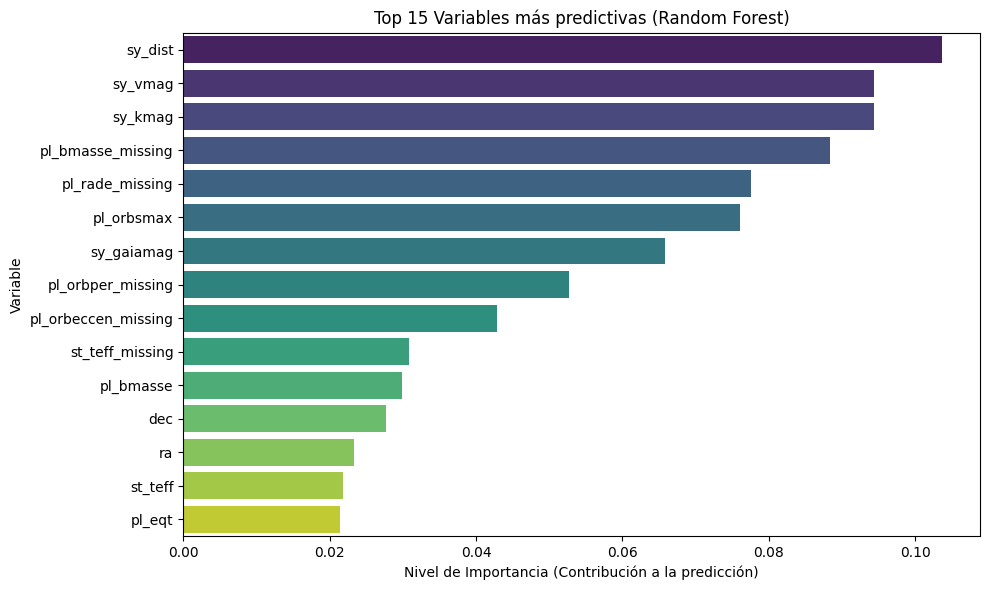

In [18]:
# ============================================================
# 17. Interpretación de Resultados
# ============================================================

# 1. Matriz de Confusión (Random Forest como modelo principal)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest (Datos Reales)")
plt.tight_layout()
plt.show()

# 2. Importancia de Variables (Feature Importance)
# Esto nos dice QUÉ reglas físicas aprendió el modelo
importances = rf_model.feature_importances_
features = X_train_bal.columns
feat_imp = pd.DataFrame({'Variable': features, 'Importancia': importances})
feat_imp = feat_imp.sort_values('Importancia', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feat_imp, hue='Variable', palette='viridis', legend=False)
plt.title("Top 15 Variables más predictivas (Random Forest)")
plt.xlabel("Nivel de Importancia (Contribución a la predicción)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


COMPARACIÓN DE MODELOS


,Modelo,Accuracy Train,Accuracy Test,F1 Macro Test,F1 Ponderado Test,Precision Ponderada Test,Recall Ponderado Test
0,Random Forest,0.9984,0.9774,0.9338,0.9782,0.9798,0.9774
1,Gradient Boosting,1.0000,0.9826,0.9313,0.9832,0.9842,0.9826
2,Regresión Logística,0.9670,0.9436,0.8475,0.9522,0.9670,0.9436



ANÁLISIS DE OVERFITTING (Diferencia Train-Test)
Random Forest: 0.0209 - Generalización aceptable
Gradient Boosting: 0.0174 - Generalización aceptable
Regresión Logística: 0.0235 - Generalización aceptable


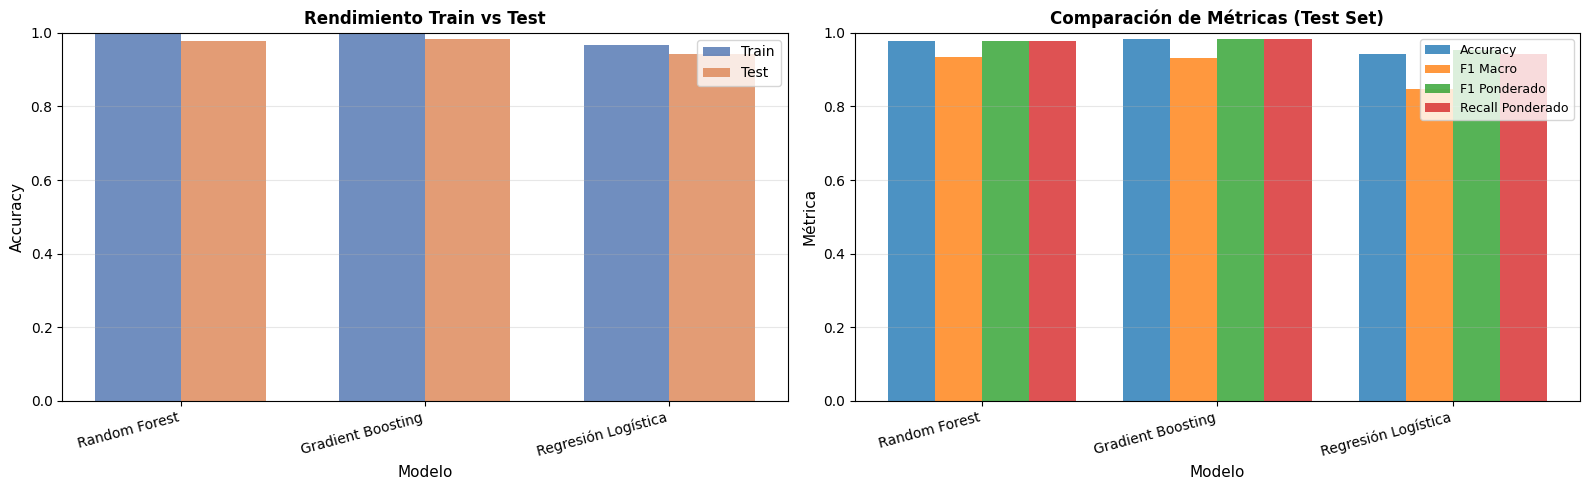


MEJOR MODELO (según F1 Macro): Random Forest (0.9338)


In [19]:
# ============================================================
# 18. Comparación de Modelos y Análisis de Overfitting
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

modelos = ['Random Forest', 'Gradient Boosting', 'Regresión Logística']
predicciones_test = [y_pred_rf, y_pred_gb, y_pred_lr]
predicciones_train = [
    rf_model.predict(X_train_bal),
    gb_model.predict(X_train_bal),
    lr_model.predict(X_train_bal_scaled)
]

# F1 macro da el mismo peso a cada clase; F1 ponderado considera su cantidad de casos.
metricas = {
    'Modelo': modelos,
    'Accuracy Train': [
        accuracy_score(y_train_bal, pred) for pred in predicciones_train
    ],
    'Accuracy Test': [
        accuracy_score(y_test, pred) for pred in predicciones_test
    ],
    'F1 Macro Test': [
        f1_score(y_test, pred, average='macro') for pred in predicciones_test
    ],
    'F1 Ponderado Test': [
        f1_score(y_test, pred, average='weighted') for pred in predicciones_test
    ],
    'Precision Ponderada Test': [
        precision_score(y_test, pred, average='weighted') for pred in predicciones_test
    ],
    'Recall Ponderado Test': [
        recall_score(y_test, pred, average='weighted') for pred in predicciones_test
    ]
}

df_metricas = pd.DataFrame(metricas)
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
mostrar(df_metricas)

# Análisis de Overfitting
print("\n" + "="*80)
print("ANÁLISIS DE OVERFITTING (Diferencia Train-Test)")
print("="*80)
for idx, modelo in enumerate(metricas['Modelo']):
    diff = metricas['Accuracy Train'][idx] - metricas['Accuracy Test'][idx]
    estado = "Overfitting detectado" if diff > 0.15 else "Generalización aceptable"
    print(f"{modelo}: {diff:.4f} - {estado}")

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Accuracy Train vs Test
x = np.arange(len(metricas['Modelo']))
width = 0.35
axes[0].bar(x - width/2, metricas['Accuracy Train'], width, label='Train', alpha=0.8, color='#4C72B0')
axes[0].bar(x + width/2, metricas['Accuracy Test'], width, label='Test', alpha=0.8, color='#DD8452')
axes[0].set_xlabel('Modelo', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Rendimiento Train vs Test', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas['Modelo'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Gráfico 2: Comparación de métricas en Test
width = 0.2
axes[1].bar(x - 1.5*width, metricas['Accuracy Test'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x - 0.5*width, metricas['F1 Macro Test'], width, label='F1 Macro', alpha=0.8)
axes[1].bar(x + 0.5*width, metricas['F1 Ponderado Test'], width, label='F1 Ponderado', alpha=0.8)
axes[1].bar(x + 1.5*width, metricas['Recall Ponderado Test'], width, label='Recall Ponderado', alpha=0.8)
axes[1].set_xlabel('Modelo', fontsize=11)
axes[1].set_ylabel('Métrica', fontsize=11)
axes[1].set_title('Comparación de Métricas (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas['Modelo'], rotation=15, ha='right')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Se prioriza F1 macro porque el dataset original está desbalanceado.
mejor_idx = np.argmax(metricas['F1 Macro Test'])
mejor_modelo_nombre = metricas['Modelo'][mejor_idx]
mejor_f1_macro = metricas['F1 Macro Test'][mejor_idx]
mejor_f1_ponderado = metricas['F1 Ponderado Test'][mejor_idx]

print(f"\nMEJOR MODELO (según F1 Macro): {mejor_modelo_nombre} ({mejor_f1_macro:.4f})")


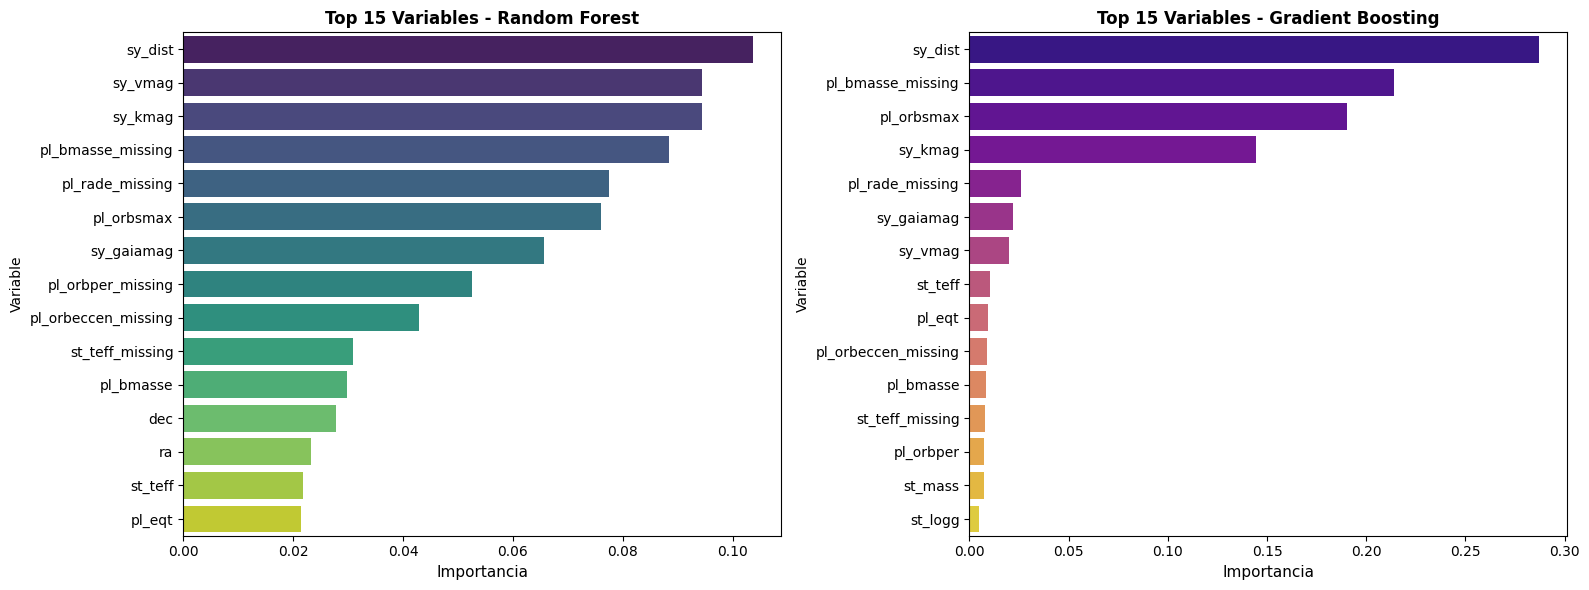

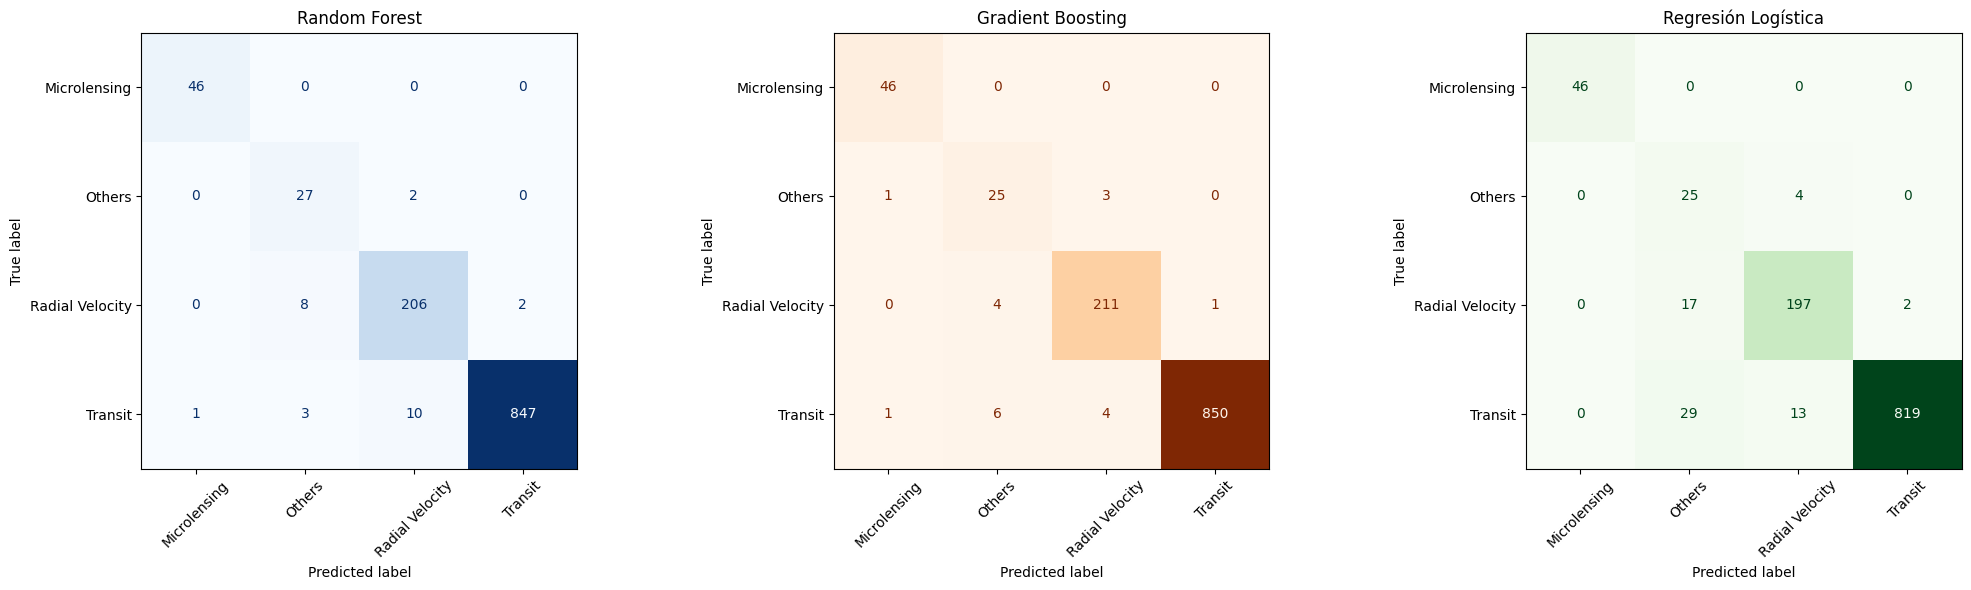


ANÁLISIS POR MÉTODO DE DESCUBRIMIENTO

RANDOM FOREST:
                 precision    recall  f1-score   support

   Microlensing     0.9787    1.0000    0.9892        46
         Others     0.7105    0.9310    0.8060        29
Radial Velocity     0.9450    0.9537    0.9493       216
        Transit     0.9976    0.9837    0.9906       861

       accuracy                         0.9774      1152
      macro avg     0.9080    0.9671    0.9338      1152
   weighted avg     0.9798    0.9774    0.9782      1152


GRADIENT BOOSTING:
                 precision    recall  f1-score   support

   Microlensing     0.9583    1.0000    0.9787        46
         Others     0.7143    0.8621    0.7812        29
Radial Velocity     0.9679    0.9769    0.9724       216
        Transit     0.9988    0.9872    0.9930       861

       accuracy                         0.9826      1152
      macro avg     0.9098    0.9565    0.9313      1152
   weighted avg     0.9842    0.9826    0.9832      1152


REGRES

In [20]:
# ============================================================
# 19. Interpretación Comparativa y Análisis por Clase
# ============================================================

# 1. Feature Importance para Gradient Boosting
gb_importances = gb_model.feature_importances_
gb_feat_imp = pd.DataFrame({'Variable': features, 'Importancia': gb_importances})
gb_feat_imp = gb_feat_imp.sort_values('Importancia', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Importancia', y='Variable', data=feat_imp, hue='Variable',
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Top 15 Variables - Random Forest", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Importancia", fontsize=11)

sns.barplot(x='Importancia', y='Variable', data=gb_feat_imp, hue='Variable',
            palette='plasma', legend=False, ax=axes[1])
axes[1].set_title("Top 15 Variables - Gradient Boosting", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Importancia", fontsize=11)

plt.tight_layout()
plt.show()

# 2. Matrices de confusión de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
matrices = [
    ('Random Forest', y_pred_rf, rf_model.classes_, 'Blues'),
    ('Gradient Boosting', y_pred_gb, gb_model.classes_, 'Oranges'),
    ('Regresión Logística', y_pred_lr, lr_model.classes_, 'Greens')
]

for ax, (nombre, pred, clases, cmap) in zip(axes, matrices):
    cm_modelo = confusion_matrix(y_test, pred, labels=clases)
    disp_modelo = ConfusionMatrixDisplay(confusion_matrix=cm_modelo, display_labels=clases)
    disp_modelo.plot(cmap=cmap, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# 3. Análisis por clase
print("\n" + "="*80)
print("ANÁLISIS POR MÉTODO DE DESCUBRIMIENTO")
print("="*80)

for nombre, pred in zip(modelos, predicciones_test):
    print(f"\n{nombre.upper()}:")
    print(classification_report(y_test, pred, digits=4))


In [21]:
# ============================================================
# 20. CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO
# ============================================================

print("\n" + "="*80)
print("CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO")
print("="*80)

diferencias = [
    metricas['Accuracy Train'][i] - metricas['Accuracy Test'][i]
    for i in range(len(modelos))
]

conclusion_text = f"""
1. DESEMPEÑO GLOBAL:
   - Mejor modelo según F1 Macro: {mejor_modelo_nombre}
   - Accuracy en test: {metricas['Accuracy Test'][mejor_idx]:.2%}
   - F1 Macro: {mejor_f1_macro:.4f}
   - F1 Ponderado: {mejor_f1_ponderado:.4f}

   El F1 Macro se utiliza como métrica principal porque da la misma importancia
   a Transit, Radial Velocity, Microlensing y Others.

2. COMPARACIÓN DE ENFOQUES:
   - Random Forest combina múltiples árboles independientes y prioriza estabilidad.
   - Gradient Boosting construye árboles secuenciales que corrigen errores previos.
   - Regresión Logística funciona como baseline lineal, simple e interpretable.

   Si los árboles superan a la Regresión Logística, esto sugiere que existen
   relaciones no lineales importantes entre las variables y el método de descubrimiento.

3. ANÁLISIS DE GENERALIZACIÓN:
   - Diferencia Train-Test (RF): {diferencias[0]:.4f}
   - Diferencia Train-Test (GB): {diferencias[1]:.4f}
   - Diferencia Train-Test (Regresión Logística): {diferencias[2]:.4f}

   Interpretación: {'Los tres modelos presentan una generalización aceptable' if max(diferencias) < 0.15 else 'Al menos un modelo presenta signos de overfitting moderado'}.

4. VARIABLES MÁS PREDICTIVAS:
   Las propiedades orbitales, físicas y estelares aportan información relevante
   para distinguir los métodos de descubrimiento.

5. CONCLUSIÓN FINAL:
   El ETL sin data leakage, el balanceo con SMOTEENN y la comparación contra
   un baseline lineal permiten evaluar de manera más sólida qué modelo captura
   mejor los patrones presentes en los datos.

6. MEJORAS FUTURAS:
   - Aplicar GridSearchCV o RandomizedSearchCV para seleccionar hiperparámetros.
   - Utilizar validación cruzada estratificada.
   - Incorporar SHAP para interpretar las predicciones.
"""

print(conclusion_text)
print("\n" + "="*80)
print("MODELADO Y ANÁLISIS COMPLETADOS")
print("="*80)



CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO

1. DESEMPEÑO GLOBAL:
   - Mejor modelo según F1 Macro: Random Forest
   - Accuracy en test: 97.74%
   - F1 Macro: 0.9338
   - F1 Ponderado: 0.9782

   El F1 Macro se utiliza como métrica principal porque da la misma importancia
   a Transit, Radial Velocity, Microlensing y Others.

2. COMPARACIÓN DE ENFOQUES:
   - Random Forest combina múltiples árboles independientes y prioriza estabilidad.
   - Gradient Boosting construye árboles secuenciales que corrigen errores previos.
   - Regresión Logística funciona como baseline lineal, simple e interpretable.

   Si los árboles superan a la Regresión Logística, esto sugiere que existen
   relaciones no lineales importantes entre las variables y el método de descubrimiento.

3. ANÁLISIS DE GENERALIZACIÓN:
   - Diferencia Train-Test (RF): 0.0209
   - Diferencia Train-Test (GB): 0.0174
   - Diferencia Train-Test (Regresión Logística): 0.0235

   Interpretación: Los tres modelos presentan 